In [1]:
#Importing Libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import random
from tensorflow.keras import layers,models
from tensorflow.keras.applications import VGG16 #import VGG16 
from tensorflow.keras.applications import DenseNet121 #import DenseNet121
from tensorflow.keras.applications.inception_v3 import InceptionV3 #import inceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import optimizers, losses
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

2026-05-14 18:19:16.695585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778782757.182580      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778782757.352953      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778782758.408507      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778782758.408565      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778782758.408568      23 computation_placer.cc:177] computation placer alr

## Load Dataset

In [2]:
dataset_path = "/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers"

print("Folder exists:", os.path.exists(dataset_path))
print("Classes:", os.listdir(dataset_path))


Folder exists: True
Classes: ['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']


## Display 2 image from each class

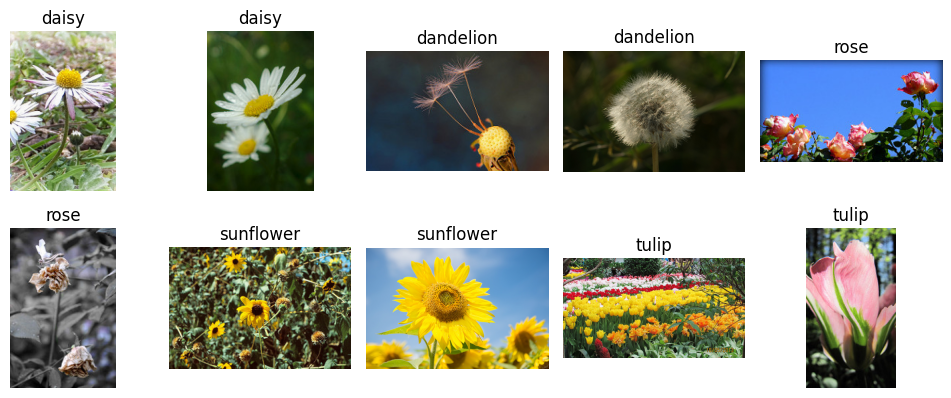

In [3]:
class_names = os.listdir(dataset_path)
class_names.sort()

plt.figure(figsize=(10, 10))

img_count = 1

for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)
    images = os.listdir(class_folder)

    # take first 2 images from each class
    for i in range(2):
        img_path = os.path.join(class_folder, images[i])
        img = Image.open(img_path)

        ax = plt.subplot(len(class_names), 5, img_count)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        plt.title(class_name)
        plt.axis("off")

        img_count += 1

plt.tight_layout()
plt.show()

Image: 6864242336_0d12713fe5_n.jpg
Shape: (240, 320, 3)
Min pixel: 0
Max pixel: 255
Data type: uint8


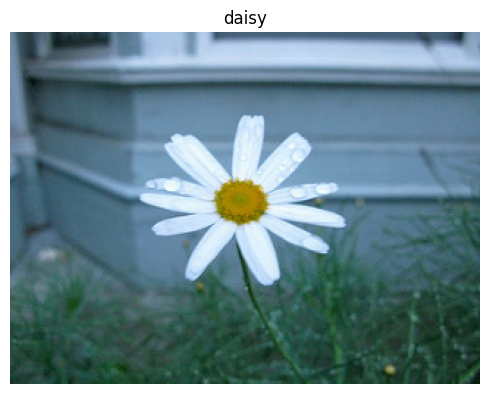

In [4]:
class_names = os.listdir(dataset_path)
class_names.sort()

num_classes = 1
num_images_per_class = 1

selected_classes = random.sample(class_names, num_classes)

plt.figure(figsize=(5, 5))

img_count = 1

for class_name in selected_classes:
    class_folder = os.path.join(dataset_path, class_name)
    images = os.listdir(class_folder)

    selected_images = random.sample(images, num_images_per_class)

    

    for img_name in selected_images:
        img_path = os.path.join(class_folder, img_name)
        
        img = Image.open(img_path)
        img_array = np.array(img)

        # Display pixel information
        print(f"Image: {img_name}")
        print(f"Shape: {img_array.shape}")
        print(f"Min pixel: {img_array.min()}")
        print(f"Max pixel: {img_array.max()}")
        print(f"Data type: {img_array.dtype}")

        plt.subplot(num_classes, num_images_per_class, img_count)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        img_count += 1

plt.tight_layout()
plt.show()

## Image resize

In [5]:
img_height = 224
img_width = 224
batch_size = 32

print(f"Dataset directory: {dataset_path}")
print(f"Target image dimensions: {img_height} x {img_width}")
print(f"Batch size: {batch_size}")

Dataset directory: /kaggle/input/datasets/alxmamaev/flowers-recognition/flowers
Target image dimensions: 224 x 224
Batch size: 32


## Train test and Validation split

#### Checking Full dataset 

In [6]:
full_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

class_names = full_ds.class_names
num_classes = len(class_names)
print("Dataset loaded successfully.")
print("Class names:", class_names)
print("Number of classes:", num_classes)


Found 4317 files belonging to 5 classes.


I0000 00:00:1778782802.815313      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778782802.821249      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Dataset loaded successfully.
Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [7]:
# Check the number of batches in the dataset
total_batches = tf.data.experimental.cardinality(full_ds).numpy()
print("Total batches:", total_batches)
# Split the dataset into training, validation, and test sets
train_size = int(0.8 * total_batches)
val_size = int(0.1 * total_batches)
#test_size = total_batches - train_size - val_size
train_ds = full_ds.take(train_size)
temp_ds = full_ds.skip(train_size)

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Total batches: 135


In [8]:
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches   = tf.data.experimental.cardinality(val_ds).numpy()
test_batches  = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Val batches:", val_batches)
print("Test batches:", test_batches)

print("\nimage counts for:")

print("Train images :", train_batches * batch_size)
print("Val images :", val_batches * batch_size)
print("Test images :", test_batches * batch_size)


Train batches: 108
Val batches: 13
Test batches: 14

image counts for:
Train images : 3456
Val images : 416
Test images : 448


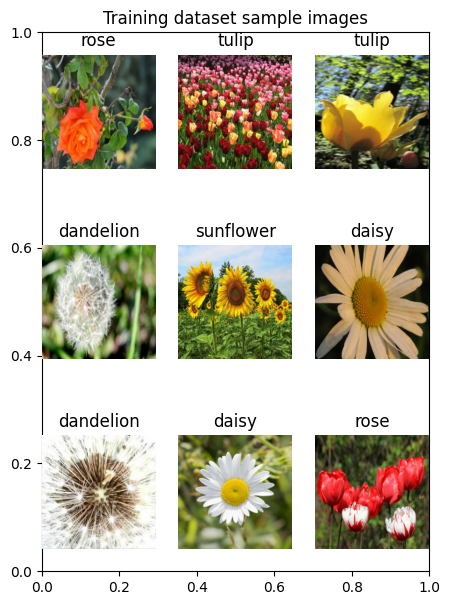

In [9]:
plt.figure(figsize=(5,7))
plt.title("Training dataset sample images")
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # ✅ important
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Data Augmentation

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),        # ~18 degrees
    tf.keras.layers.RandomTranslation(0.1, 0.1), # 10%
    tf.keras.layers.RandomZoom(0.1),
])


# Data Normalization

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)


In [12]:
# Apply data augmentation and normalization to the training dataset
AUTOTUNE = tf.data.AUTOTUNE #auto-tune the data loading and preprocessing for optimal performance

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization_layer(x), training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)


In [13]:
#this step is to apply normalization to the validation and test datasets without data augmentation, 
# as we want to evaluate the model on unaltered data.
val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)


## Compare Augmented image with original image 

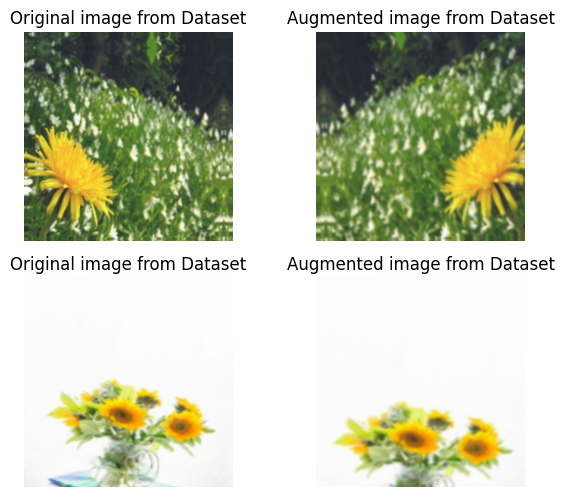

In [14]:
for images, labels in train_ds.take(1):
    original_images = images
    original_labels = labels

augmented_images = data_augmentation(original_images, training=True)

plt.figure(figsize=(6, 10))

for i in range(2):
    # Original
    ax = plt.subplot(4, 2, 2*i + 1)
    plt.imshow(original_images[i])
    plt.title("Original image from Dataset")
    plt.axis("off")

    # Augmented
    ax = plt.subplot(4, 2, 2*i + 2)
    plt.imshow(augmented_images[i])
    plt.title("Augmented image from Dataset")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Load VGG baseline model 

In [15]:
# Load the VGG16 model with pre-trained ImageNet weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
#freeze the base layer
base_model.trainable = False

vgg_model = base_model.output
vgg_model = Flatten()(vgg_model)
vgg_model = Dense(256,activation='relu')(vgg_model) # 256 neurons
vgg_model = Dropout(0.5)(vgg_model)
vgg_model = Dense(5,activation='softmax')(vgg_model)
vgg_model = Model(inputs=base_model.input,outputs=vgg_model)

In [17]:
#compile the model with optimize the performance of vgg16
vgg_model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [18]:
vgg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [19]:
#train the model
epochs = 20

history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/20


I0000 00:00:1778782857.766800      81 service.cc:152] XLA service 0x239b0030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778782857.766837      81 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778782857.766841      81 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778782858.318218      81 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/108 ━━━━━━━━━━━━━━━━━━━━ 1:06:32 37s/step - accuracy: 0.1562 - loss: 2.2501

I0000 00:00:1778782871.857560      81 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


108/108 ━━━━━━━━━━━━━━━━━━━━ 61s 217ms/step - accuracy: 0.4550 - loss: 1.3857 - val_accuracy: 0.7620 - val_loss: 0.6889
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 42s 184ms/step - accuracy: 0.7221 - loss: 0.7761 - val_accuracy: 0.7909 - val_loss: 0.6034
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 43s 195ms/step - accuracy: 0.7420 - loss: 0.7147 - val_accuracy: 0.8029 - val_loss: 0.5489
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 44s 207ms/step - accuracy: 0.7766 - loss: 0.6118 - val_accuracy: 0.8053 - val_loss: 0.5499
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 44s 213ms/step - accuracy: 0.7992 - loss: 0.5766 - val_accuracy: 0.8173 - val_loss: 0.5149
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 44s 209ms/step - accuracy: 0.8040 - loss: 0.5411 - val_accuracy: 0.8125 - val_loss: 0.5281
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 45s 216ms/step - accuracy: 0.8151 - loss: 0.5159 - val_accuracy: 0.8438 - val_loss: 0.4509
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 44s 210ms/step - accuracy: 0.8153 - loss: 0.4970 - val

In [20]:
train_loss_vgg, train_acc = vgg_model.evaluate(train_ds)
val_loss_vgg, val_acc = vgg_model.evaluate(val_ds)
test_loss_vgg, test_acc = vgg_model.evaluate(test_ds)
print("\nVGG16 Model Performance:")
print("Training Loss:", round(train_loss_vgg, 4))
print("Training Accuracy:", round(train_acc * 100, 2), "%")

print("\nValidation Loss:", round(val_loss_vgg, 4))
print("Validation Accuracy:", round(val_acc * 100, 2), "%")


print("\nTest Loss:", round(test_loss_vgg, 4))
print("Test Accuracy:", round(test_acc * 100, 2), "%")


108/108 ━━━━━━━━━━━━━━━━━━━━ 42s 187ms/step - accuracy: 0.9125 - loss: 0.2545
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - accuracy: 0.9240 - loss: 0.2865
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8694 - loss: 0.4093

VGG16 Model Performance:
Training Loss: 0.2553
Training Accuracy: 91.52 %

Validation Loss: 0.3656
Validation Accuracy: 88.46 %

Test Loss: 0.449
Test Accuracy: 84.94 %


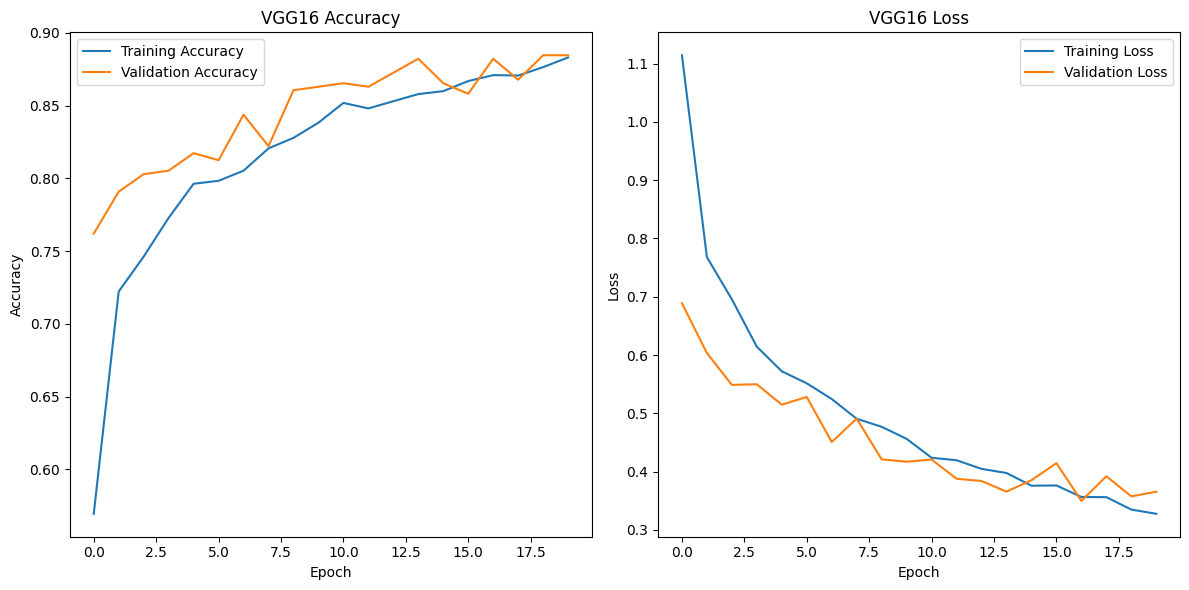

In [21]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("VGG16 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
#Get Predictions from Test Set
vgg_y_true = []
vgg_y_pred = []

for images, labels in test_ds:
    predictions = vgg_model.predict(images)
    vgg_y_true.extend(labels.numpy())
    vgg_y_pred.extend(np.argmax(predictions, axis=1))

vgg_y_true = np.array(vgg_y_true)
vgg_y_pred = np.array(vgg_y_pred)
print("\nClassification Output for Test set:\n")
print(classification_report(vgg_y_true, vgg_y_pred, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step

Classification Output for Test set:

              precision    recall  f1-score   support

       daisy       0.92      0.82      0.87        73
   dandelion       0.95      0.87      0.91       102
        rose       0.69      0.87      0.77        75
   sunflower       0.88      0.87      0.87        84
       tulip       0.83      0.82      0.83       111

    accuracy                           0.85       445
   macro avg       0.86      0.85      

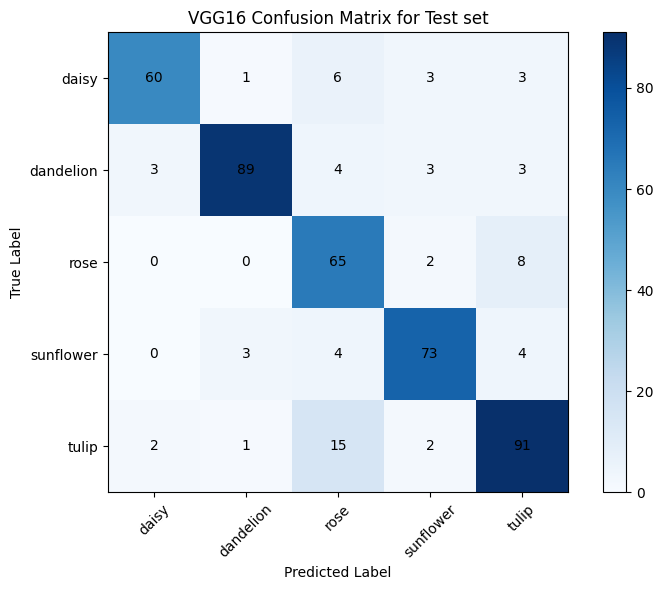

In [23]:
cm = confusion_matrix(vgg_y_true, vgg_y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm,cmap="Blues")
plt.title("VGG16 Confusion Matrix for Test set")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [24]:
vgg_model.save("vgg16_kaggle_flower.keras")

## Inception V3 model

In [25]:
base_inceptionV3 = tf.keras.applications.InceptionV3(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

#unfreeze the base layer
base_inceptionV3.trainable = True

for layer in base_inceptionV3.layers[:-50]:
    layer.trainable = False



87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
model_inc = tf.keras.Sequential([
    base_inceptionV3,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(5, activation="softmax")
])


In [27]:
model_inc.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
model_inc.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,637 (85.18 MB)

 Trainable params: 7,699,653 (29.37 MB)

 Non-trainable params: 14,629,984 (55.81 MB)

In [29]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [30]:
history_inc = model_inc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
    #callbacks =[early_stop]
)

Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 65s 146ms/step - accuracy: 0.5677 - loss: 1.1479 - val_accuracy: 0.8750 - val_loss: 0.3999
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.8375 - loss: 0.4526 - val_accuracy: 0.9038 - val_loss: 0.3109
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.8826 - loss: 0.3261 - val_accuracy: 0.9014 - val_loss: 0.2907
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - accuracy: 0.9127 - loss: 0.2496 - val_accuracy: 0.9183 - val_loss: 0.2550
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.9291 - loss: 0.2048 - val_accuracy: 0.9303 - val_loss: 0.2431
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.9491 - loss: 0.1511 - val_accuracy: 0.9327 - val_loss: 0.2407
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.9442 - loss: 0.1466 - val_accuracy: 0.9519 - val_loss: 0.1804
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.9517 - loss: 0.1279 -

In [31]:
train_loss_inc, train_acc_inc = model_inc.evaluate(train_ds)
val_loss_inc, val_acc_inc = model_inc.evaluate(val_ds)
test_loss_inc, test_acc_inc = model_inc.evaluate(test_ds)
print("\nInceptionV3 Model Performance:")
print("Training Loss:", round(train_loss_inc, 4))
print("Training Accuracy:", round(train_acc_inc * 100, 2), "%")

print("\nValidation Loss:", round(val_loss_inc, 4))
print("Validation Accuracy:", round(val_acc_inc * 100, 2), "%")

print("\nTest Loss:", round(test_loss_inc, 4))
print("Test Accuracy:", round(test_acc_inc * 100, 2), "%")

108/108 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.9971 - loss: 0.0138
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9645 - loss: 0.1590
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 603ms/step - accuracy: 0.9147 - loss: 0.4215

InceptionV3 Model Performance:
Training Loss: 0.0114
Training Accuracy: 99.77 %

Validation Loss: 0.2181
Validation Accuracy: 95.19 %

Test Loss: 0.3682
Test Accuracy: 91.24 %


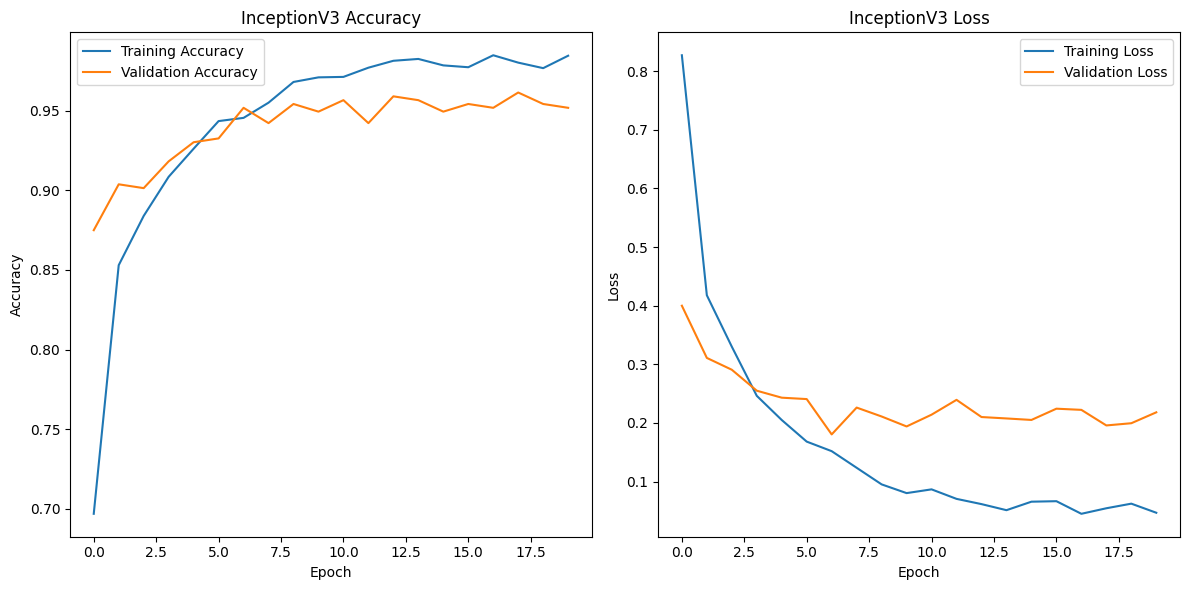

In [32]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_inc.history["accuracy"], label="Training Accuracy")
plt.plot(history_inc.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("InceptionV3 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_inc.history["loss"], label="Training Loss")
plt.plot(history_inc.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("InceptionV3 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
#Get Predictions from Test Set
inc_y_true = []
inc_y_pred = []

for images, labels in test_ds: 
    predictions = model_inc.predict(images)
    inc_y_true.extend(labels.numpy())
    inc_y_pred.extend(np.argmax(predictions, axis=1))

inc_y_true = np.array(inc_y_true)
inc_y_pred = np.array(inc_y_pred) #np array to convert list to array for classification report
print("InceptionV3 Classification Output for Test set:\n")
print(classification_report(inc_y_true, inc_y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
InceptionV3 Classification Output for Test set:

              precision    recall  f1-score   support

       daisy       0.86      0.92      0.89        73
   dandelion       0.97      0.89      0.93       102
        rose       0.93      0.91      0.92        75
   sunflower       0.92      0.92      0.92        84
       tulip       0.89      0.93      0.91       111

    accuracy                           0.91       445
   macro avg       0.91      0.

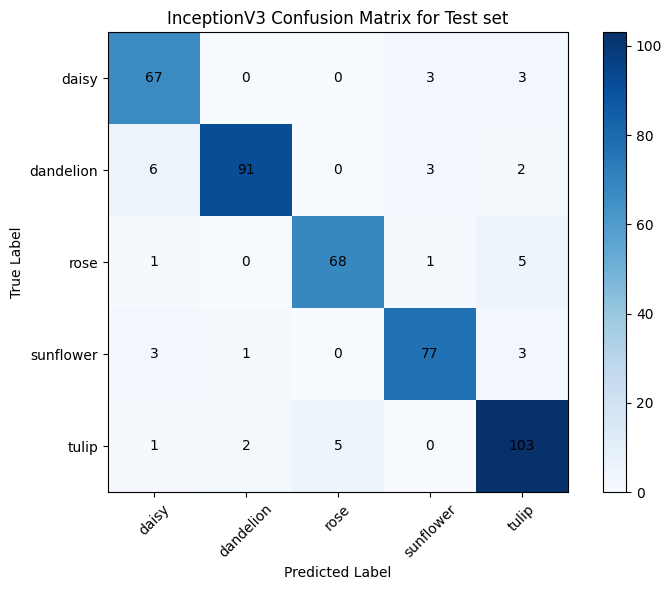

In [34]:
cm = confusion_matrix(inc_y_true, inc_y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm,cmap="Blues")
plt.title("InceptionV3 Confusion Matrix for Test set")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [35]:
model_inc.save("inceptionV3_kaggle_flower.keras")
print("InceptionV3 model trained and saved successfully.")


InceptionV3 model trained and saved successfully.


## DenseNet121

In [36]:
denseNet_base = DenseNet121(weights='imagenet', include_top=False, pooling='avg', input_shape=(img_height, img_width, 3))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [37]:
denseNet_base.trainable = False

In [38]:
densenet_model = tf.keras.Sequential([
    denseNet_base,
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(5, activation="softmax")
])

In [39]:
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
densenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,213 (27.86 MB)

 Trainable params: 264,197 (1.01 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

In [41]:
history_densenet = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 71s 199ms/step - accuracy: 0.3516 - loss: 1.7851 - val_accuracy: 0.7500 - val_loss: 0.7314
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.7028 - loss: 0.7977 - val_accuracy: 0.8317 - val_loss: 0.4762
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.7691 - loss: 0.6466 - val_accuracy: 0.8365 - val_loss: 0.4248
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.8086 - loss: 0.5324 - val_accuracy: 0.8702 - val_loss: 0.3653
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.8350 - loss: 0.4790 - val_accuracy: 0.8750 - val_loss: 0.3470
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.8403 - loss: 0.4347 - val_accuracy: 0.8822 - val_loss: 0.3283
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.8576 - loss: 0.3868 - val_accuracy: 0.8918 - val_loss: 0.3159
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - accuracy: 0.8651 - loss: 0.3812 -

In [42]:
train_loss_densenet, train_acc_densenet = densenet_model.evaluate(train_ds)
val_loss_densenet, val_acc_densenet = densenet_model.evaluate(val_ds)
test_loss_densenet, test_acc_densenet = densenet_model.evaluate(test_ds)
print("\nDenseNet121 Model Performance:")
print("Training Loss:", round(train_loss_densenet, 4))
print("Training Accuracy:", round(train_acc_densenet * 100, 2), "%")

print("\nValidation Loss:", round(val_loss_densenet, 4))
print("Validation Accuracy:", round(val_acc_densenet * 100, 2), "%")

print("\nTest Loss:", round(test_loss_densenet, 4))
print("Test Accuracy:", round(test_acc_densenet * 100, 2), "%")

108/108 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.9434 - loss: 0.1671
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9222 - loss: 0.2236
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9080 - loss: 0.2936

DenseNet121 Model Performance:
Training Loss: 0.1791
Training Accuracy: 93.32 %

Validation Loss: 0.2543
Validation Accuracy: 91.11 %

Test Loss: 0.3182
Test Accuracy: 89.21 %


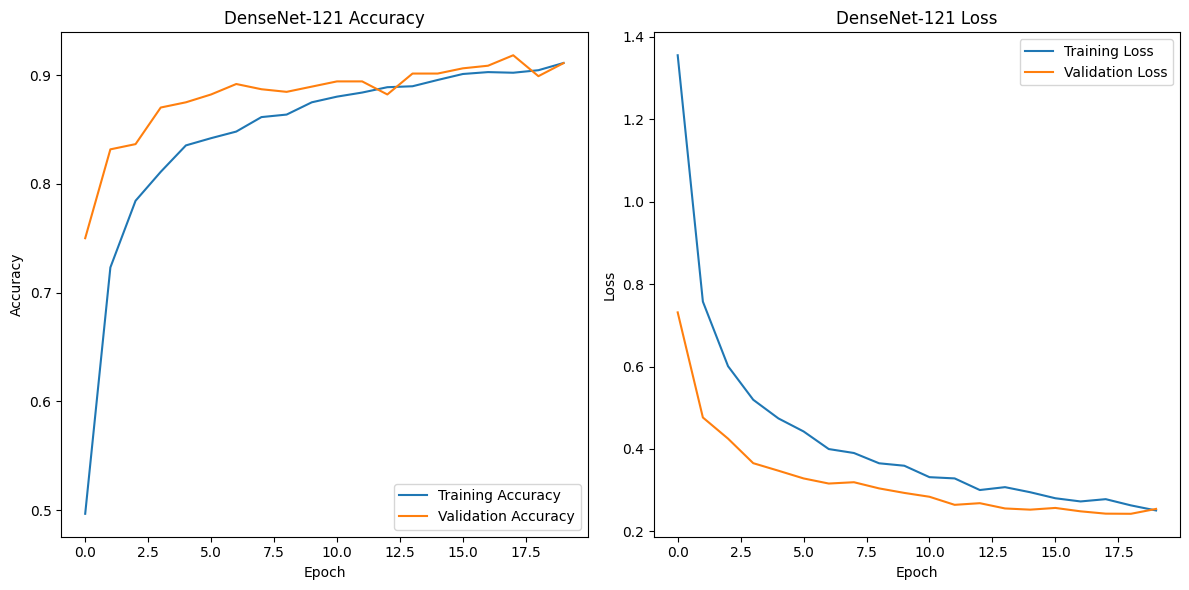

In [43]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_densenet.history["accuracy"], label="Training Accuracy")
plt.plot(history_densenet.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("DenseNet-121 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_densenet.history["loss"], label="Training Loss")
plt.plot(history_densenet.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet-121 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
#Get Predictions from Test Set
densenet_y_true = []
densenet_y_pred = []

for images, labels in test_ds: #showing the predictions for each batch of test dataset
    predictions = densenet_model.predict(images)
    densenet_y_true.extend(labels.numpy())
    densenet_y_pred.extend(np.argmax(predictions, axis=1))

densenet_y_true = np.array(densenet_y_true)
densenet_y_pred = np.array(densenet_y_pred)
print("DenseNet-121 Classification Output for Test set:\n")
print(classification_report(densenet_y_true, densenet_y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
DenseNet-121 Classification Output for Test set:

              precision    recall  f1-score   support

       daisy       0.87      0.97      0.92        73
   dandelion       0.93      0.90      0.92       102
        rose       0.80      0.87      0.83        75
   sunflower       0.97      0.88      0.93        84
       tulip       0.89      0.86      0.87       111

    accuracy                           0.89       445
   macro avg       0.89   

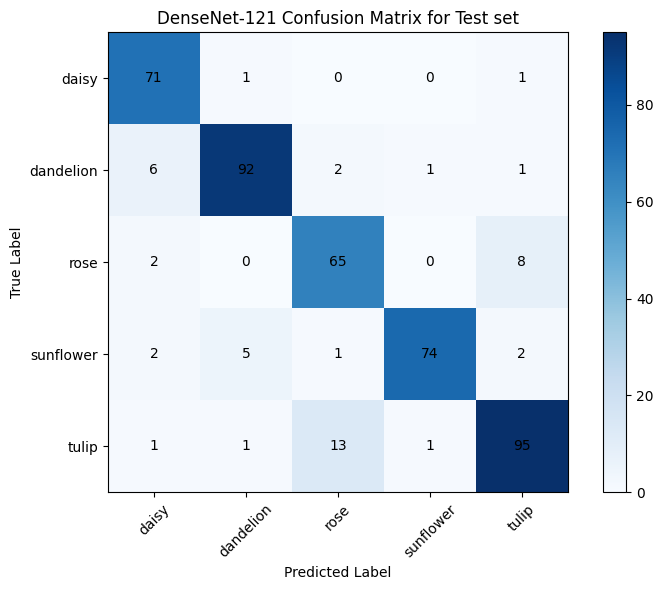

In [45]:
cm = confusion_matrix(densenet_y_true, densenet_y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm,cmap="Blues")
plt.title("DenseNet-121 Confusion Matrix for Test set")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [46]:
densenet_model.save("densenet121_kaggle_flower.keras")

### Ensemble Learning (Weighted Voting)

The ensemble model achieved a slight improvement over the best individual model. This is because the individual models share similar architectures and feature extraction patterns, resulting in highly correlated predictions. As a result, the ensemble provides limited additional benefit.

In [47]:
vgg_model = load_model("vgg16_kaggle_flower.keras")
densenet_model = load_model("densenet121_kaggle_flower.keras")
inception_model = load_model("inceptionV3_kaggle_flower.keras")

print("Models loaded successfully..")

Models loaded successfully..


#### Generate prediction for each model

In [48]:
vgg_pred = vgg_model.predict(test_ds)
dense_pred = densenet_model.predict(test_ds)
inception_pred = inception_model.predict(test_ds)
#reload the model to get the predictions for ensemble method

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 961ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 536ms/step


In [49]:
#checking individual model performance
y_true = np.concatenate([y for x, y in test_ds], axis=0)

vgg_acc = accuracy_score(y_true, np.argmax(vgg_pred, axis=1))
dense_acc = accuracy_score(y_true, np.argmax(dense_pred, axis=1))
inception_acc = accuracy_score(y_true, np.argmax(inception_pred, axis=1))
print("VGG16:", round(vgg_acc * 100, 2), "%")
print("DenseNet-121:", round(dense_acc * 100, 2), "%")
print("InceptionV3:", round(inception_acc * 100, 2), "%")

VGG16: 84.94 %
DenseNet-121: 89.21 %
InceptionV3: 91.24 %


In [50]:
print(vgg_pred.shape)
print(dense_pred.shape)
print(inception_pred.shape)

(445, 5)
(445, 5)
(445, 5)


#### To implement weighted voting, We need to find the best weight distribution for each model

In [51]:
weight_sets = {
    "Equal Voting": (0.33, 0.33, 0.33),

    "VGG16 Dominant": (0.6, 0.2, 0.2),
    "DenseNet Dominant": (0.2, 0.6, 0.2),
    "Inception Dominant": (0.2, 0.2, 0.6),

    "Strong VGG16 Dominant": (0.7, 0.15, 0.15),
    "Strong DenseNet Dominant": (0.15, 0.7, 0.15),
    "Strong Inception Dominant": (0.15, 0.15, 0.7),

    "Balanced Strong Models": (0.1, 0.4, 0.5),
    "Inception Focused": (0.1, 0.2, 0.7),
    "DenseNet + Inception": (0.1, 0.45, 0.45)
}

results = []

for name, (w_vgg, w_dense, w_inception) in weight_sets.items():

    ensemble_pred = (
        w_vgg * vgg_pred +
        w_dense * dense_pred +
        w_inception * inception_pred
    )
    #Final predicted class 
    y_pred_ensemble = np.argmax(ensemble_pred, axis=1)
    #Calculate accuracy for the ensemble predictions
    ensemble_acc = accuracy_score(y_true, y_pred_ensemble)

    results.append([
        name,
        w_vgg,
        w_dense,
        w_inception,
        round(ensemble_acc * 100, 2)
    ])

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Ensemble Strategy",
        "VGG16 Weight",
        "DenseNet-121 Weight",
        "InceptionV3 Weight",
        "Accuracy (%)"
    ]
)

# Sort by best accuracy
results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

print("\n\t\t\t========== Weighted Voting Comparison ==========\n")

print(results_df)


			========== Weighted Voting Comparison ==========

           Ensemble Strategy  VGG16 Weight  DenseNet-121 Weight  InceptionV3 Weight  Accuracy (%)
0     Balanced Strong Models          0.10                 0.40                0.50         92.13
1         Inception Dominant          0.20                 0.20                0.60         92.13
2       DenseNet + Inception          0.10                 0.45                0.45         91.91
3          Inception Focused          0.10                 0.20                0.70         91.91
4  Strong Inception Dominant          0.15                 0.15                0.70         91.91
5               Equal Voting          0.33                 0.33                0.33         91.69
6          DenseNet Dominant          0.20                 0.60                0.20         91.01
7   Strong DenseNet Dominant          0.15                 0.70                0.15         90.34
8             VGG16 Dominant          0.60                 0.20 

In [52]:
# DISPLAY BEST ENSEMBLE STRATEGY
best_result = results_df.iloc[0]

print("\n========== Best Ensemble Strategy ==========\n")

print(f"Strategy            : {best_result['Ensemble Strategy']}")
print(f"VGG16 Weight        : {best_result['VGG16 Weight']}")
print(f"DenseNet121 Weight  : {best_result['DenseNet-121 Weight']}")
print(f"InceptionV3 Weight  : {best_result['InceptionV3 Weight']}")
print(f"Best Accuracy       : {best_result['Accuracy (%)']}%")


========== Best Ensemble Strategy ==========

Strategy            : Balanced Strong Models
VGG16 Weight        : 0.1
DenseNet121 Weight  : 0.4
InceptionV3 Weight  : 0.5
Best Accuracy       : 92.13%


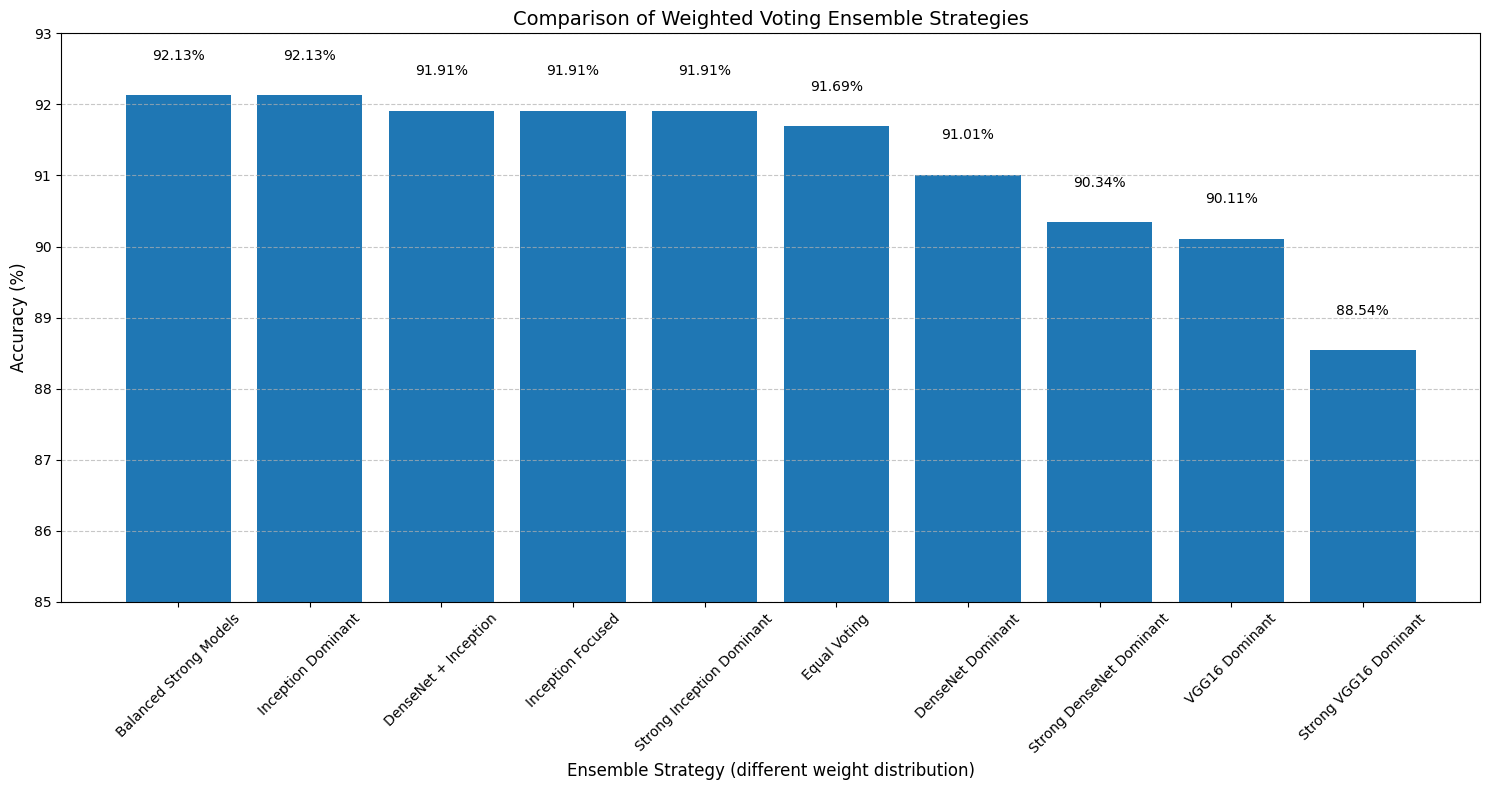

In [53]:
# Plot figure
plt.figure(figsize=(15,8))

# Bar chart
bars = plt.bar(
    results_df["Ensemble Strategy"],
    results_df["Accuracy (%)"]
)

# Labels and title
plt.xlabel("Ensemble Strategy (different weight distribution)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Comparison of Weighted Voting Ensemble Strategies", fontsize=14)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Set y-axis range for better visualization
plt.ylim(85, 93)

# Add accuracy labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}%",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout
plt.tight_layout()

# Show graph
plt.show()

In [54]:
#build the final ensemble model using the best weights from the weighted voting comparison
final_ensemble_pred = (
    0.1 * vgg_pred +
    0.45 * dense_pred +
    0.45 * inception_pred
)
y_pred_finalEnsemble = np.argmax(final_ensemble_pred, axis=1)

In [55]:
print("\n========== Classification Report For Weighted Voting ==========\n")
print(classification_report(
    y_true,
    y_pred_finalEnsemble,
    target_names=class_names
))
final_accuracy_ensemble = accuracy_score(
    y_true,
    y_pred_finalEnsemble
)

# Convert to percentage
final_accuracy_percentage = final_accuracy_ensemble * 100
print(f"\nFinal Weighted Voting Test Accuracy : {final_accuracy_percentage:.2f}%")


========== Classification Report For Weighted Voting ==========

              precision    recall  f1-score   support

       daisy       0.87      0.95      0.91        73
   dandelion       0.99      0.92      0.95       102
        rose       0.87      0.91      0.89        75
   sunflower       0.95      0.93      0.94        84
       tulip       0.90      0.90      0.90       111

    accuracy                           0.92       445
   macro avg       0.92      0.92      0.92       445
weighted avg       0.92      0.92      0.92       445


Final Weighted Voting Test Accuracy : 91.91%


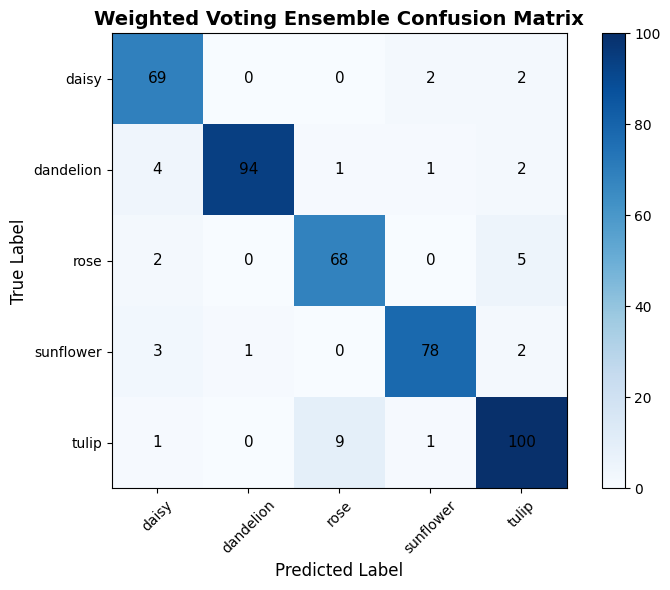

In [56]:
cm = confusion_matrix(
    y_true,
    y_pred_finalEnsemble
)
plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")
# Title and labels
plt.title(
    "Weighted Voting Ensemble Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "True Label",
    fontsize=12
)

# Tick labels using flower names
plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.colorbar()
plt.tight_layout()
plt.show()

#### Test-Time Augmentation to improve robustness

In [57]:
# TTA setting
tta_steps = 3
tta_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05), # ~18 degrees
    tf.keras.layers.RandomZoom(0.03) # 3% zoom
])

In [58]:
def get_tta_predictions(model, dataset, tta_steps=5):

    tta_predictions = []

    for step in range(tta_steps):

        print(f"TTA Step {step+1}/{tta_steps}")

        augmented_batches = []

        # Apply augmentation batch-by-batch
        for images, labels in dataset:

            augmented_images = tta_augmentation(
                images,
                training=True
            )

            augmented_batches.append(augmented_images)

        # Combine all batches
        augmented_images_all = tf.concat(
            augmented_batches,
            axis=0
        )

        # Predict
        preds = model.predict(
            augmented_images_all,
            verbose=0
        )

        tta_predictions.append(preds)

    # Average all TTA predictions
    return np.mean(tta_predictions, axis=0)

In [59]:
# GENERATE TTA PREDICTIONS FOR EACH MODEL
# one model 3 step 
vgg_tta_pred = get_tta_predictions(
    vgg_model,
    test_ds,
    tta_steps
)
print ("TTA predictions generated for VGG16 model.")
dense_tta_pred = get_tta_predictions(
    densenet_model,
    test_ds,
    tta_steps
)
print("TTA predictions generated for DenseNet-121 model.")
inception_tta_pred = get_tta_predictions(
    inception_model,
    test_ds,
    tta_steps
)
print("TTA predictions generated for InceptionV3 model.")
print("\nTTA predictions generated for all models.")

TTA Step 1/3
TTA Step 2/3
TTA Step 3/3
TTA predictions generated for VGG16 model.
TTA Step 1/3
TTA Step 2/3
TTA Step 3/3
TTA predictions generated for DenseNet-121 model.
TTA Step 1/3
TTA Step 2/3
TTA Step 3/3
TTA predictions generated for InceptionV3 model.

TTA predictions generated for all models.


In [60]:
#Applying weighted voting to TTA predictions with best weight distribution
final_tta_ensemble_pred = (
    (0.10 * vgg_tta_pred) +
    (0.45 * dense_tta_pred) +
    (0.45 * inception_tta_pred)
)
#final predicted class for TTA ensemble
y_pred_tta = np.argmax(
    final_tta_ensemble_pred,
    axis=1
)

In [61]:
tta_accuracy = accuracy_score(
    y_true,
    y_pred_tta
)
# DISPLAY FINAL RESULT AND CONVERT TO PERCENTAGE
print("\n========== Weighted Voting + TTA ==========\n")

print(f"Final TTA Ensemble Accuracy : {tta_accuracy * 100:.2f}%")


========== Weighted Voting + TTA ==========

Final TTA Ensemble Accuracy : 92.58%



========== Final Model Comparison ==========

                   Model  Accuracy (%)
0                  VGG16         84.94
1            DenseNet121         89.21
2            InceptionV3         91.24
3        Weighted Voting         91.91
4  Weighted Voting + TTA         92.58


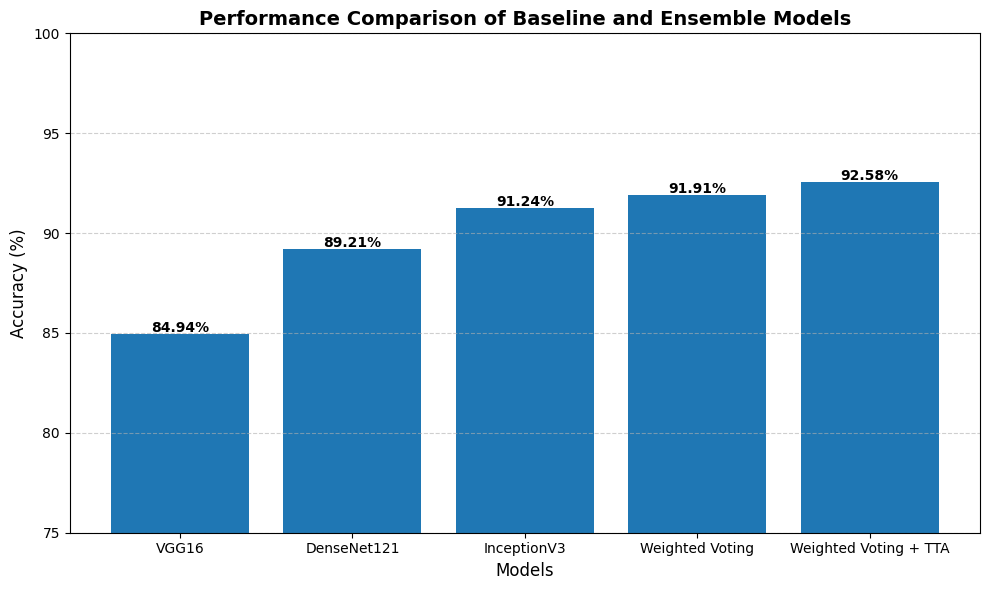

In [62]:
# FINAL MODEL COMPARISON
comparison_results = {

    "Model": [

        "VGG16",
        "DenseNet121",
        "InceptionV3",
        "Weighted Voting",
        "Weighted Voting + TTA"
    ],

    "Accuracy (%)": [

        round(vgg_acc * 100, 2),
        round(dense_acc * 100, 2),
        round(inception_acc * 100, 2),
        round(final_accuracy_percentage, 2),
        round(tta_accuracy * 100, 2)
    ]
}

# CREATE DATAFRAME

comparison_df = pd.DataFrame(comparison_results)
# DISPLAY TABLE
print("\n========== Final Model Comparison ==========\n")

print(comparison_df)

plt.figure(figsize=(10,6))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Performance Comparison of Baseline and Ensemble Models",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Models",
    fontsize=12
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=12
)

# Better visualization range
plt.ylim(75, 100)

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()


plt.show()